In [2]:
# 导入依赖与辅助函数（中文注释）
import time
import selfies
import rdkit
import random
import numpy as np
import pandas as pd
from rdkit import Chem
from selfies import encoder, decoder
from rdkit.Chem import MolFromSmiles as smi2mol
from rdkit.Chem import MolToSmiles as mol2smi
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

# 将一个 RDKit 分子对象随机化为不同的 SMILES 表达（但化学结构相同）
def randomize_smiles(mol):
    if not mol:
        return None
    Chem.Kekulize(mol)  # 去芳香化，便于随机化生成不同的 SMILES
    return rdkit.Chem.MolToSmiles(
        mol,
        canonical=False,
        doRandom=True,
        isomericSmiles=False,
        kekuleSmiles=True,
    )

# 规范化 SMILES（返回 RDKit 分子与规范化后的 SMILES）
def sanitize_smiles(smi):
    try:
        mol = smi2mol(smi, sanitize=True)
        smi_canon = mol2smi(mol, isomericSmiles=False, canonical=True)
        return (mol, smi_canon, True)
    except:
        return (None, None, False)

# 将 SELFIES 字符串分解为符号列表
def get_selfie_chars(selfie):
    chars_selfie = []
    while selfie != '':
        chars_selfie.append(selfie[selfie.find('['): selfie.find(']')+1])
        selfie = selfie[selfie.find(']')+1:]
    return chars_selfie

# 对单个 SELFIES 执行一次随机突变（插入/替换/删除），直到得到有效分子
def mutate_selfie(selfie, max_molecules_len, write_fail_cases=False):
    valid = False
    fail_counter = 0
    chars_selfie = get_selfie_chars(selfie)

    while not valid:
        fail_counter += 1
        alphabet = list(selfies.get_semantic_robust_alphabet())  # 语义鲁棒字母表
        choice_ls = [1, 2, 3]  # 1=插入；2=替换；3=删除
        random_choice = np.random.choice(choice_ls, 1)[0]

        if random_choice == 1:  # 插入
            random_index = np.random.randint(len(chars_selfie)+1)
            random_character = np.random.choice(alphabet, size=1)[0]
            selfie_mutated_chars = chars_selfie[:random_index] + [random_character] + chars_selfie[random_index:]
        elif random_choice == 2:  # 替换
            random_index = np.random.randint(len(chars_selfie))
            random_character = np.random.choice(alphabet, size=1)[0]
            if random_index == 0:
                selfie_mutated_chars = [random_character] + chars_selfie[random_index+1:]
            else:
                selfie_mutated_chars = chars_selfie[:random_index] + [random_character] + chars_selfie[random_index+1:]
        elif random_choice == 3:  # 删除
            random_index = np.random.randint(len(chars_selfie))
            if random_index == 0:
                selfie_mutated_chars = chars_selfie[random_index+1:]
            else:
                selfie_mutated_chars = chars_selfie[:random_index] + chars_selfie[random_index+1:]

        selfie_mutated = "".join(x for x in selfie_mutated_chars)

        try:
            smiles = decoder(selfie_mutated)
            mol, smiles_canon, done = sanitize_smiles(smiles)
            if len(selfie_mutated_chars) > max_molecules_len or smiles_canon == "":
                done = False
            valid = bool(done)
        except:
            valid = False
            if fail_counter > 1 and write_fail_cases:
                with open("selfie_failure_cases.txt", "a+", encoding="utf-8") as f:
                    f.write(f"尝试将 SELFIES {''.join(chars_selfie)} 突变为 {selfie_mutated} 失败\n")

    return (selfie_mutated, smiles_canon)

# 连续进行 num_mutations 次突变
def get_mutated_SELFIES(selfies_ls, num_mutations):
    mutated_selfies = []
    for s in selfies_ls:
        str_chars = get_selfie_chars(s)
        max_len = len(str_chars) + num_mutations
        temp_s = s
        for _ in range(num_mutations):
            mutated_s, _ = mutate_selfie(temp_s, max_len)
            temp_s = mutated_s
        mutated_selfies.append(temp_s)
    return mutated_selfies

In [2]:
# 读取文本文件中的 SMILES 列表（每行一个），去除空行与前缀标记
smiles_list = []
with open('data/SMILES_List.txt', 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        if line.startswith('---'):
            # 忽略形如 "--- Molecules generated from ... ---" 的分隔行
            continue
        smiles_list.append(line)

print(f"共读取到 {len(smiles_list)} 条 SMILES。示例：{smiles_list[:3]}")

共读取到 414 条 SMILES。示例：['BrCc1ccccc1', 'C/C=C/COP(C)(=O)F', 'C1CSCCO1']


In [3]:
# 批量扩充：将每个输入 SMILES 扩充到 1000 个唯一分子（基于 STONED SELFIES）
num_molecules_to_generate = 1000            # 每个起始分子的目标数量
num_mutation_ls = [1, 2, 3, 4, 5]           # 不同突变强度

expanded_map = {}  # { 原始smi: [生成的规范SMILES, ...] }

for smi in smiles_list:
    print(f"开始扩充：{smi}")
    mol = smi2mol(smi)
    if mol is None:
        print(f"  跳过无效 SMILES：{smi}")
        continue

    canon_smi_set = set()
    num_random_samples = 200  # 起始随机样本数
    start_time = time.time()

    while len(canon_smi_set) < num_molecules_to_generate:
        # 1) 为同一分子生成多种随机 SMILES 作为不同起点
        randomized_smile_orderings = [randomize_smiles(mol) for _ in range(num_random_samples)]
        selfies_ls = [encoder(x) for x in randomized_smile_orderings if x is not None]

        # 2) 对每种起点进行不同强度的 SELFIES 突变
        for num_mutations in num_mutation_ls:
            if len(canon_smi_set) >= num_molecules_to_generate:
                break
            selfies_mut = get_mutated_SELFIES(selfies_ls.copy(), num_mutations=num_mutations)
            smiles_back = [decoder(x) for x in selfies_mut]

            # 3) 规范化与去重
            for item in smiles_back:
                _, smi_canon, ok = sanitize_smiles(item)
                if ok and smi_canon:
                    canon_smi_set.add(smi_canon)

        elapsed = time.time() - start_time
        print(f"  已生成 {len(canon_smi_set)} / {num_molecules_to_generate} 个（用时 {elapsed:.1f}s）")

        # 若数量不足，提升随机起点多样性
        if len(canon_smi_set) < num_molecules_to_generate:
            num_random_samples += 100

    expanded_map[smi] = list(canon_smi_set)[:num_molecules_to_generate]
    print(f"  完成：{smi} -> {len(expanded_map[smi])} 个")

print("所有 SMILES 扩充完成。")

开始扩充：BrCc1ccccc1
  已生成 783 / 1000 个（用时 0.9s）
  已生成 1092 / 1000 个（用时 1.3s）
  完成：BrCc1ccccc1 -> 1000 个
开始扩充：C/C=C/COP(C)(=O)F
  已生成 844 / 1000 个（用时 0.9s）
  已生成 1002 / 1000 个（用时 1.1s）
  完成：C/C=C/COP(C)(=O)F -> 1000 个
开始扩充：C1CSCCO1
  已生成 760 / 1000 个（用时 0.8s）
  已生成 1022 / 1000 个（用时 1.1s）
  完成：C1CSCCO1 -> 1000 个
开始扩充：C1CSCCS1
  已生成 704 / 1000 个（用时 0.8s）
  已生成 1137 / 1000 个（用时 1.3s）
  完成：C1CSCCS1 -> 1000 个
开始扩充：C=CS(=O)(=O)C=C
  已生成 748 / 1000 个（用时 0.8s）
  已生成 1035 / 1000 个（用时 1.1s）
  完成：C=CS(=O)(=O)C=C -> 1000 个
开始扩充：C=CS(=O)C=C
  已生成 733 / 1000 个（用时 0.7s）
  已生成 1192 / 1000 个（用时 1.2s）
  完成：C=CS(=O)C=C -> 1000 个
开始扩充：C=CSCCCSC=C
  已生成 851 / 1000 个（用时 0.9s）
  已生成 1192 / 1000 个（用时 1.2s）
  完成：C=CSCCCSC=C -> 1000 个
开始扩充：C=CSCCSC=C
  已生成 820 / 1000 个（用时 0.8s）
  已生成 1135 / 1000 个（用时 1.1s）
  完成：C=CSCCSC=C -> 1000 个
开始扩充：CC#N
  已生成 491 / 1000 个（用时 0.5s）
  已生成 990 / 1000 个（用时 1.3s）
  已生成 1017 / 1000 个（用时 1.4s）
  完成：CC#N -> 1000 个
开始扩充：CC(C)(C)CCOP(C)(=O)F
  已生成 897 / 1000 个（用时 1.1s）
  已生成 1042 / 1000

In [4]:
# 保存扩充结果到 CSV：两列（original_smi, generated_smi）
csv_rows = []
for original_smi, gen_list in expanded_map.items():
    for gen_smi in gen_list:
        csv_rows.append({"original_smi": original_smi, "generated_smi": gen_smi})

df = pd.DataFrame(csv_rows)
df.to_csv("expanded_molecules.csv", index=False, encoding="utf-8")
print("已保存到 expanded_molecules.csv")

已保存到 expanded_molecules.csv


In [5]:
# 合并原始与生成的所有分子，去重后保存为 TXT
all_unique = set(smiles_list)
for gen_list in expanded_map.values():
    all_unique.update(gen_list)

with open("all_unique_molecules.txt", "w", encoding="utf-8") as f:
    for smi in sorted(all_unique):
        f.write(smi + "\n")

print(f"已保存共 {len(all_unique)} 条唯一分子到 all_unique_molecules.txt")

已保存共 335331 条唯一分子到 all_unique_molecules.txt


In [4]:
# 独立筛选单元格：从文件读取分子并筛选包含H或C的分子
from rdkit.Chem import MolFromSmiles as smi2mol

# 从文件读取所有唯一分子
all_molecules = []
try:
    with open("all_unique_molecules.txt", "r", encoding="utf-8") as f:
        all_molecules = [line.strip() for line in f if line.strip()]
    print(f"成功读取 {len(all_molecules)} 条分子")
except FileNotFoundError:
    print("未找到 all_unique_molecules.txt 文件，请先运行前面的单元格生成该文件")
    all_molecules = []

# 筛选包含H或C的分子
filtered_molecules = []

for smi in all_molecules:
    mol = smi2mol(smi)
    if mol is None:
        continue
    
    # 检查分子是否包含碳(C)或氢(H)原子
    has_c_or_h = False
    for atom in mol.GetAtoms():
        if atom.GetSymbol() in ['C', 'H']:
            has_c_or_h = True
            break
    
    if has_c_or_h:
        filtered_molecules.append(smi)

# 保存筛选后的分子
if filtered_molecules:
    with open("filtered_molecules_with_C_or_H.txt", "w", encoding="utf-8") as f:
        for smi in sorted(filtered_molecules):
            f.write(smi + "\n")
    
    print(f"原始分子数量: {len(all_molecules)}")
    print(f"包含C或H的分子数量: {len(filtered_molecules)}")
    print(f"已保存到 filtered_molecules_with_C_or_H.txt")
else:
    print("没有找到符合条件的分子")

成功读取 335331 条分子
原始分子数量: 335331
包含C或H的分子数量: 331817
已保存到 filtered_molecules_with_C_or_H.txt


对表expanded_molecules.csv（只展示前三行）中的分子按第二列进行去重，如果第二列中有两个SMILES表示一个分子则保留一个同时第一列的数据不变
original_smi,generated_smi
BrCc1ccccc1,BrCCB1C=CC=CC1
BrCc1ccccc1,[C-]C=CC=CC=CCBr
BrCc1ccccc1,C=CC=CC

In [1]:
# 独立去重单元格：对 expanded_molecules.csv 按第二列分子等价去重并导出
import os
import pandas as pd
from rdkit.Chem import MolFromSmiles as smi2mol, MolToSmiles as mol2smi

inp = "expanded_molecules.csv"
outp = "expanded_molecules_unique.csv"

if not os.path.exists(inp):
    raise FileNotFoundError(f"未找到输入文件: {inp}")

# 读取并校验列
df = pd.read_csv(inp)
required_cols = {"original_smi", "generated_smi"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"缺少必要列: {missing}")

# 将第二列的 SMILES 规范化为 RDKit 标准 SMILES，用于判等
def canonize(smi: str) -> str | None:
    try:
        mol = smi2mol(str(smi), sanitize=True)
        if mol is None:
            return None
        return mol2smi(mol, isomericSmiles=False, canonical=True)
    except Exception:
        return None

orig_count = len(df)

# 计算规范 SMILES，用于去重键
df["canonical_generated"] = df["generated_smi"].apply(canonize)

# 丢弃解析失败的行
valid = df[df["canonical_generated"].notna() & (df["canonical_generated"] != "")].copy()

# 按规范 SMILES 去重：保留首次出现，第一列（original_smi）保持该行不变
unique_df = valid.drop_duplicates(subset=["canonical_generated"], keep="first").copy()

# 输出仅保留原始两列（保留被保留行中的原始 generated_smi 字符串）
out_cols = ["original_smi", "generated_smi"]
unique_df[out_cols].to_csv(outp, index=False, encoding="utf-8")

print(f"输入条数: {orig_count}")
print(f"可解析条数: {len(valid)}")
print(f"去重后条数: {len(unique_df)}")
print(f"已保存到 {outp}")

[21:07:40] WARNING: not removing hydrogen atom without neighbors
[21:07:40] WARNING: not removing hydrogen atom without neighbors
[21:07:42] WARNING: not removing hydrogen atom without neighbors
[21:07:42] WARNING: not removing hydrogen atom without neighbors
[21:07:45] WARNING: not removing hydrogen atom without neighbors
[21:07:45] WARNING: not removing hydrogen atom without neighbors
[21:07:45] WARNING: not removing hydrogen atom without neighbors
[21:07:45] WARNING: not removing hydrogen atom without neighbors
[21:07:46] WARNING: not removing hydrogen atom without neighbors
[21:07:46] WARNING: not removing hydrogen atom without neighbors
[21:07:46] WARNING: not removing hydrogen atom without neighbors
[21:07:46] WARNING: not removing hydrogen atom without neighbors
[21:07:46] WARNING: not removing hydrogen atom without neighbors
[21:07:46] WARNING: not removing hydrogen atom without neighbors
[21:07:47] WARNING: not removing hydrogen atom without neighbors
[21:07:47] WARNING: not r

输入条数: 414000
可解析条数: 414000
去重后条数: 335261
已保存到 expanded_molecules_unique.csv


提取分子骨架

输入: CCOP(C)(=O)F  | 环数: 0
Murcko骨架: (无环→空)
Murcko通用骨架: (无环/失败)
拓扑[*]骨架(保留键型): ****(*)(*)=*
拓扑[*]骨架(单键): ****(*)(*)*
最长路径主链: [C][C]O[P](=O)F
2-core骨架(回退含最长路径): [C][C]O[P](=O)F
碳骨架: CCCC(C)(C)C


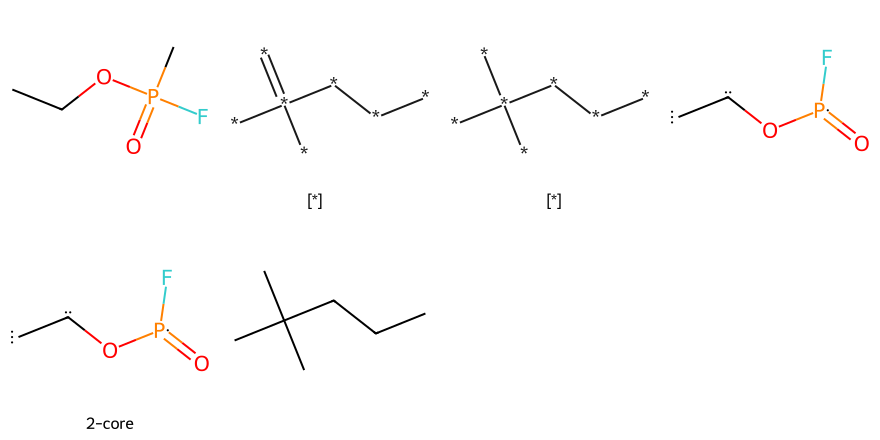

In [18]:
# 独立单元格：无环分子骨架的多种提取方式（拓扑[*]、最长路径、2-core、碳骨架）
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import rdmolops
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem import MolFromSmiles as smi2mol, MolToSmiles as mol2smi
from IPython.display import display
import numpy as np

def nonempty(m):
    return m is not None and m.GetNumAtoms() > 0

def heavy_degree(atom):
    return sum(1 for n in atom.GetNeighbors() if n.GetAtomicNum() > 1)

def submol_from_atom_set(mol, keep_atoms):
    if not keep_atoms:
        return None
    keep = set(int(i) for i in keep_atoms)
    rw = Chem.RWMol(mol)
    # 按索引从大到小删除不保留的原子
    to_remove = sorted([a.GetIdx() for a in rw.GetAtoms() if a.GetIdx() not in keep], reverse=True)
    for idx in to_remove:
        rw.RemoveAtom(idx)
    sub = rw.GetMol()
    Chem.SanitizeMol(sub, sanitizeOps=Chem.SanitizeFlags.SANITIZE_KEKULIZE|Chem.SanitizeFlags.SANITIZE_FINDRADICALS|Chem.SanitizeFlags.SANITIZE_SETAROMATICITY, catchErrors=True)
    return sub

def make_topology_star(mol, keep_bond_order=True):
    rw = Chem.RWMol(mol)
    for a in rw.GetAtoms():
        a.SetAtomicNum(0)  # [*]
        a.SetIsAromatic(False)
        a.SetFormalCharge(0)
        a.SetNoImplicit(True)
        a.SetChiralTag(Chem.rdchem.ChiralType.CHI_UNSPECIFIED)
    if not keep_bond_order:
        for b in rw.GetBonds():
            b.SetBondType(Chem.rdchem.BondType.SINGLE)
            b.SetIsAromatic(False)
    m = rw.GetMol()
    return m

def make_carbon_skeleton(mol):
    rw = Chem.RWMol(mol)
    for a in rw.GetAtoms():
        a.SetAtomicNum(6)  # C
        a.SetIsAromatic(False)
        a.SetFormalCharge(0)
        a.SetNoImplicit(False)
        a.SetChiralTag(Chem.rdchem.ChiralType.CHI_UNSPECIFIED)
    for b in rw.GetBonds():
        b.SetBondType(Chem.rdchem.BondType.SINGLE)
        b.SetIsAromatic(False)
    m = rw.GetMol()
    return m

# ...existing code...
# ...existing code...
# ...existing code...
def longest_path_submol_keep_OH_H(mol):
    """
    最长路径主链：
    - 去掉所有H，仅保留OH中的H
    - 保留与主链相邻的F
    """
    dmat = rdmolops.GetDistanceMatrix(mol)
    if dmat.size == 0:
        return None
    i, j = np.unravel_index(int(dmat.argmax()), dmat.shape)
    path_atoms = set(map(int, rdmolops.GetShortestPath(mol, int(i), int(j))))
    if not path_atoms:
        return None

    # 只保留主链重原子
    keep_atoms = {idx for idx in path_atoms if mol.GetAtomWithIdx(idx).GetAtomicNum() > 1}

    # 额外保留与主链相邻的F
    keep_neighbor_atomic_nums = {7, 8, 9, 11, 15, 16, 17, 33}  # N,O,F,Na,P,S,Cl,As
    for idx in list(keep_atoms):
        a = mol.GetAtomWithIdx(idx)
        for n in a.GetNeighbors():
            if n.GetAtomicNum() in keep_neighbor_atomic_nums:
                keep_atoms.add(int(n.GetIdx()))

    # 先抽子结构（不带H）
    submol = submol_from_atom_set(mol, keep_atoms)
    if submol is None:
        return None

    # 显式加氢，再删掉非OH的氢
    submolH = Chem.AddHs(submol, addCoords=False)
    rw = Chem.RWMol(submolH)

    to_remove = []
    for atom in rw.GetAtoms():
        if atom.GetAtomicNum() == 1:
            # 仅保留连接到氧(O)的氢
            if not any(n.GetAtomicNum() == 8 for n in atom.GetNeighbors()):
                to_remove.append(atom.GetIdx())
    for idx in sorted(to_remove, reverse=True):
        rw.RemoveAtom(idx)

    # 禁用隐式氢，避免出现 N-H 等隐式氢
    for atom in rw.GetAtoms():
        if atom.GetAtomicNum() != 1:
            atom.SetNoImplicit(True)

    cleaned = rw.GetMol()
    cleaned.UpdatePropertyCache(strict=False)
    Chem.SanitizeMol(cleaned, catchErrors=True)
    return cleaned
# ...existing code...

def core2_submol(mol):
    # 只考虑重原子图做2-core（迭代剥离叶子）
    keep = set(a.GetIdx() for a in mol.GetAtoms() if a.GetAtomicNum() > 1)
    if not keep:
        return None
    changed = True
    while changed:
        changed = False
        to_drop = []
        for idx in list(keep):
            a = mol.GetAtomWithIdx(idx)
            deg = sum(1 for n in a.GetNeighbors() if n.GetAtomicNum() > 1 and n.GetIdx() in keep)
            if deg <= 1:
                to_drop.append(idx)
        if to_drop:
            changed = True
            for idx in to_drop:
                keep.discard(idx)
    # 如果core为空，回退到最长路径（仅保留OH的H）
    if not keep:
        return longest_path_submol_keep_OH_H(mol)
    return submol_from_atom_set(mol, keep)
# ...existing code...

# 修改为你的无环分子（示例：无环）
smi = "O=P(F)(C)OCC"

mol = smi2mol(smi)
if mol is None:
    raise ValueError("无效的 SMILES")

ring_count = mol.GetRingInfo().NumRings()

# 1) 标准 Murcko（有环时有效）
murcko = MurckoScaffold.GetScaffoldForMol(mol)
murcko = murcko if nonempty(murcko) else None

# 2) 通用骨架（泛化）
murcko_gen = None
if murcko is not None:
    try:
        murcko_gen = MurckoScaffold.MakeScaffoldGeneric(murcko)
    except Exception:
        murcko_gen = None

# 3) 拓扑[*]骨架（保留原键型与支化）
topo_star = make_topology_star(mol, keep_bond_order=True)

# 4) 拓扑[*]（全部设为单键）
topo_star_single = make_topology_star(mol, keep_bond_order=False)

# 5) 最长路径主链
lp = longest_path_submol_keep_OH_H(mol)

# 6) 2-core 骨架（为空则自动回退到最长路径）
core2 = core2_submol(mol)

# 7) 碳骨架（全部换成C-单键）
carbon = make_carbon_skeleton(mol)

def smi_or_none(m):
    return mol2smi(m, isomericSmiles=False) if nonempty(m) else ""

print(f"输入: {mol2smi(mol, isomericSmiles=False)}  | 环数: {ring_count}")
print("Murcko骨架:", smi_or_none(murcko) or "(无环→空)")
print("Murcko通用骨架:", smi_or_none(murcko_gen) or "(无环/失败)")
print("拓扑[*]骨架(保留键型):", smi_or_none(topo_star))
print("拓扑[*]骨架(单键):", smi_or_none(topo_star_single))
print("最长路径主链:", smi_or_none(lp) or "(失败)")
print("2-core骨架(回退含最长路径):", smi_or_none(core2) or "(失败)")
print("碳骨架:", smi_or_none(carbon))

# 可视化（过滤空分子）
labels_mols = [
    ("原分子", mol),
    ("Murcko", murcko),
    ("Murcko通用", murcko_gen),
    ("拓扑[*]保键型", topo_star),
    ("拓扑[*]单键", topo_star_single),
    ("最长路径", lp),
    ("2-core", core2),
    ("碳骨架", carbon),
]
mols_viz = [m for _, m in labels_mols if nonempty(m)]
legends = [lab for lab, m in labels_mols if nonempty(m)]
img = Draw.MolsToGridImage(mols_viz, molsPerRow=min(4, len(mols_viz)), subImgSize=(220,220), legends=legends)
display(img)

CCOP(C)(=O)F


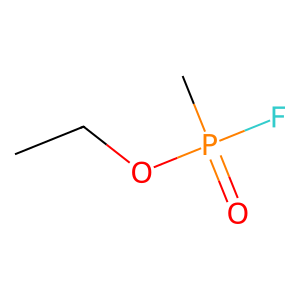

In [5]:
from rdkit import Chem
from rdkit.Chem import Draw
def get_main_chain_with_FO(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    # 含环 → 用 Murcko 骨架
    if mol.GetRingInfo().NumRings() > 0:
        from rdkit.Chem.Scaffolds import MurckoScaffold
        scaffold = MurckoScaffold.GetScaffoldForMol(mol)
        return Chem.MolToSmiles(scaffold)

    # 找最长碳链
    carbon_atoms = [a.GetIdx() for a in mol.GetAtoms() if a.GetSymbol() == "C"]
    longest_path = []
    for i in carbon_atoms:
        for j in carbon_atoms:
            if i >= j:
                continue
            path = Chem.rdmolops.GetShortestPath(mol, i, j)
            if len(path) > len(longest_path):
                longest_path = path

    if not longest_path:
        return None

    # 扩展：加入主链上直接连接的 F 和 O 原子
    atom_indices = set(longest_path)
    for idx in longest_path:
        atom = mol.GetAtomWithIdx(idx)
        for nbr in atom.GetNeighbors():
            if nbr.GetSymbol() in ["F", "O"]:
                atom_indices.add(nbr.GetIdx())

    # 使用 EditableMol 安全构建子分子
    em = Chem.EditableMol(Chem.Mol())
    idx_map = {}
    for i, old_idx in enumerate(sorted(atom_indices)):
        old_atom = mol.GetAtomWithIdx(old_idx)
        new_atom = Chem.Atom(old_atom.GetSymbol())
        idx_map[old_idx] = em.AddAtom(new_atom)

    # 添加子分子内部的键
    for bond in mol.GetBonds():
        a1, a2 = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        if a1 in atom_indices and a2 in atom_indices:
            em.AddBond(idx_map[a1], idx_map[a2], bond.GetBondType())

    submol = em.GetMol()
    Chem.SanitizeMol(submol)
    return Chem.MolToSmiles(submol)

print(get_main_chain_with_FO("CCOP(C)(=O)F"))


smiles = get_main_chain_with_FO("CCOP(C)(=O)F")  

# 转为分子对象
mol = Chem.MolFromSmiles(smiles)

# 显示结构图
Draw.MolToImage(mol, size=(300, 300))


###  Generating the chemical subspace of Celecoxib while preserving a specific substructure

We will preserve the structure marked in red for Celecoxib: 

<img src="https://github.com/aspuru-guzik-group/stoned-selfies/blob/main/data/struct_pres.png?raw=True" width="250" />

We write a function with RDKit that can detect the highlighted structure ( substructure_preserver ). While performing mutations with SELFIES, we check if the function returns True (has the substructure). Else, the algorithm is asked to retry/perform a different mutation. Have a look at the specific line: 
```
if len(selfie_mutated_chars) > max_molecules_len or smiles_canon=="" or substructure_preserver(mol)==False:
```

In [ ]:
def substructure_preserver(mol):
    """
    Check for substructure violates
    Return True: contains a substructure violation
    Return False: No substructure violation
    """        
    
    if mol.HasSubstructMatch(rdkit.Chem.MolFromSmarts('NS(=O)(=O)c1ccc(-n2cccn2)cc1')) == True:
        return True # The has substructure! 
    else: 
        return False # Molecule does not have substructure!

def mutate_selfie(selfie, max_molecules_len, write_fail_cases=False):
    '''Return a mutated selfie string (only one mutation on slefie is performed)
    
    Mutations are done until a valid molecule is obtained 
    Rules of mutation: With a 33.3% propbabily, either: 
        1. Add a random SELFIE character in the string
        2. Replace a random SELFIE character with another
        3. Delete a random character
    
    Parameters:
    selfie            (string)  : SELFIE string to be mutated 
    max_molecules_len (int)     : Mutations of SELFIE string are allowed up to this length
    write_fail_cases  (bool)    : If true, failed mutations are recorded in "selfie_failure_cases.txt"
    
    Returns:
    selfie_mutated    (string)  : Mutated SELFIE string
    smiles_canon      (string)  : canonical smile of mutated SELFIE string
    '''
    valid=False
    fail_counter = 0
    chars_selfie = get_selfie_chars(selfie)
    
    while not valid:
        fail_counter += 1
                
        alphabet = list(selfies.get_semantic_robust_alphabet()) # 34 SELFIE characters 

        choice_ls = [1, 2, 3] # 1=Insert; 2=Replace; 3=Delete
        random_choice = np.random.choice(choice_ls, 1)[0]
        
        # Insert a character in a Random Location
        if random_choice == 1: 
            random_index = np.random.randint(len(chars_selfie)+1)
            random_character = np.random.choice(alphabet, size=1)[0]
            
            selfie_mutated_chars = chars_selfie[:random_index] + [random_character] + chars_selfie[random_index:]

        # Replace a random character 
        elif random_choice == 2:                         
            random_index = np.random.randint(len(chars_selfie))
            random_character = np.random.choice(alphabet, size=1)[0]
            if random_index == 0:
                selfie_mutated_chars = [random_character] + chars_selfie[random_index+1:]
            else:
                selfie_mutated_chars = chars_selfie[:random_index] + [random_character] + chars_selfie[random_index+1:]
                
        # Delete a random character
        elif random_choice == 3: 
            random_index = np.random.randint(len(chars_selfie))
            if random_index == 0:
                selfie_mutated_chars = chars_selfie[random_index+1:]
            else:
                selfie_mutated_chars = chars_selfie[:random_index] + chars_selfie[random_index+1:]
                
        else: 
            raise Exception('Invalid Operation trying to be performed')

        selfie_mutated = "".join(x for x in selfie_mutated_chars)
        sf = "".join(x for x in chars_selfie)
        
        try:
            smiles = decoder(selfie_mutated)
            mol, smiles_canon, done = sanitize_smiles(smiles)
            if len(selfie_mutated_chars) > max_molecules_len or smiles_canon=="" or substructure_preserver(mol)==False:
                done = False
            if done:
                valid = True
            else:
                valid = False
        except:
            valid=False
            if fail_counter > 1 and write_fail_cases == True:
                f = open("selfie_failure_cases.txt", "a+")
                f.write('Tried to mutate SELFIE: '+str(sf)+' To Obtain: '+str(selfie_mutated) + '\n')
                f.close()
    
    return (selfie_mutated, smiles_canon)

In [ ]:
smi     = 'CC1=CC=C(C=C1)C2=CC(=NN2C3=CC=C(C=C3)S(=O)(=O)N)C(F)(F)F'   # Celecoxib
fp_type = 'ECFP4'


total_time = time.time()
# num_random_samples = 50000 # For a more exhaustive search! 
num_random_samples = 100     
num_mutation_ls    = [1, 2, 3, 4, 5]

mol = Chem.MolFromSmiles(smi)
if mol == None: 
    raise Exception('Invalid starting structure encountered')

start_time = time.time()
randomized_smile_orderings  = [randomize_smiles(mol) for _ in range(num_random_samples)]

# Convert all the molecules to SELFIES
selfies_ls = [encoder(x) for x in randomized_smile_orderings]
print('Randomized molecules (in SELFIES) time: ', time.time()-start_time)


all_smiles_collect = []
all_smiles_collect_broken = []

start_time = time.time()
for num_mutations in num_mutation_ls: 
    # Mutate the SELFIES: 
    selfies_mut = get_mutated_SELFIES(selfies_ls.copy(), num_mutations=num_mutations)

    # Convert back to SMILES: 
    smiles_back = [decoder(x) for x in selfies_mut]
    all_smiles_collect = all_smiles_collect + smiles_back
    all_smiles_collect_broken.append(smiles_back)


print('Mutation obtainment time (back to smiles): ', time.time()-start_time)


# Work on:  all_smiles_collect
start_time = time.time()
canon_smi_ls = []
for item in all_smiles_collect: 
    mol, smi_canon, did_convert = sanitize_smiles(item)
    if mol == None or smi_canon == '' or did_convert == False: 
        raise Exception('Invalid smile string found')
    canon_smi_ls.append(smi_canon)
canon_smi_ls        = list(set(canon_smi_ls))
print('Unique mutated structure obtainment time: ', time.time()-start_time)

start_time = time.time()
canon_smi_ls_scores = get_fp_scores(canon_smi_ls, target_smi=smi, fp_type=fp_type)
print('Fingerprint calculation time: ', time.time()-start_time)
print('Total time: ', time.time()-total_time)

# Molecules with fingerprint similarity > 0.8
indices_thresh_8 = [i for i,x in enumerate(canon_smi_ls_scores) if x > 0.8]
mols_8 = [Chem.MolFromSmiles(canon_smi_ls[idx]) for idx in indices_thresh_8]

# Molecules with fingerprint similarity > 0.6
indices_thresh_6 = [i for i,x in enumerate(canon_smi_ls_scores) if x > 0.6 and x < 0.8]
mols_6 = [Chem.MolFromSmiles(canon_smi_ls[idx]) for idx in indices_thresh_6]

# Molecules with fingerprint similarity > 0.4
indices_thresh_4 = [i for i,x in enumerate(canon_smi_ls_scores) if x > 0.4 and x < 0.6]
mols_4 = [Chem.MolFromSmiles(canon_smi_ls[idx]) for idx in indices_thresh_4]

对expanded_molecules_unique.csv里的数据进行筛选，筛选后新建一个csv，具体筛选过程如下：
对于每一行的两个SMILES，按longest_path_submol_keep_OH_H最长路径的方法提取第一个SMILES的骨架并参照substructure_preserver方法判断第二列的扩展分子是否包含了第一个SMILES的骨架，包含的保留，不包含的删掉

In [ ]:
# 独立筛选单元格：按“最长路径主链(仅保留OH中的H，且保留邻接F/O/S/As/P/N/Cl/Na)”作为骨架，过滤是否被第二列包含
import os
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import rdmolops
from rdkit.Chem import MolFromSmiles as smi2mol, MolToSmiles as mol2smi

inp = "expanded_molecules_unique.csv"
outp = "expanded_molecules_unique_filtered.csv"

if not os.path.exists(inp):
    raise FileNotFoundError(f"未找到输入文件: {inp}")

def nonempty(m):
    return m is not None and m.GetNumAtoms() > 0

def submol_from_atom_set(mol, keep_atoms):
    if not keep_atoms:
        return None
    keep = set(int(i) for i in keep_atoms)
    rw = Chem.RWMol(mol)
    # 按索引从大到小删除不保留的原子
    to_remove = sorted([a.GetIdx() for a in rw.GetAtoms() if a.GetIdx() not in keep], reverse=True)
    for idx in to_remove:
        rw.RemoveAtom(idx)
    sub = rw.GetMol()
    Chem.SanitizeMol(sub, sanitizeOps=Chem.SanitizeFlags.SANITIZE_KEKULIZE|Chem.SanitizeFlags.SANITIZE_FINDRADICALS|Chem.SanitizeFlags.SANITIZE_SETAROMATICITY, catchErrors=True)
    return sub

# 注意：以下函数与前面单元格保持一致（不做改变的语义），仅在此处复用
# 最长路径主链：去掉所有H，仅保留OH中的H；额外保留与主链相邻的 F、O、S、As、P、N、Cl、Na

def longest_path_submol_keep_OH_H(mol):
    dmat = rdmolops.GetDistanceMatrix(mol)
    if dmat.size == 0:
        return None
    i, j = np.unravel_index(int(dmat.argmax()), dmat.shape)
    path_atoms = set(map(int, rdmolops.GetShortestPath(mol, int(i), int(j))))
    if not path_atoms:
        return None

    # 只保留主链重原子
    keep_atoms = {idx for idx in path_atoms if mol.GetAtomWithIdx(idx).GetAtomicNum() > 1}

    # 额外保留与主链相邻的 F、O、S、As、P、N、Cl、Na
    keep_neighbor_atomic_nums = {7, 8, 9, 11, 15, 16, 17, 33}  # N,O,F,Na,P,S,Cl,As
    for idx in list(keep_atoms):
        a = mol.GetAtomWithIdx(idx)
        for n in a.GetNeighbors():
            if n.GetAtomicNum() in keep_neighbor_atomic_nums:
                keep_atoms.add(int(n.GetIdx()))

    # 先抽子结构（不带H）
    submol = submol_from_atom_set(mol, keep_atoms)
    if submol is None:
        return None

    # 显式加氢，再删掉非OH的氢
    submolH = Chem.AddHs(submol, addCoords=False)
    rw = Chem.RWMol(submolH)

    to_remove = []
    for atom in rw.GetAtoms():
        if atom.GetAtomicNum() == 1:
            # 仅保留连接到氧(O)的氢
            if not any(n.GetAtomicNum() == 8 for n in atom.GetNeighbors()):
                to_remove.append(atom.GetIdx())
    for idx in sorted(to_remove, reverse=True):
        rw.RemoveAtom(idx)

    # 禁用隐式氢，避免出现隐式H
    for atom in rw.GetAtoms():
        if atom.GetAtomicNum() != 1:
            atom.SetNoImplicit(True)

    cleaned = rw.GetMol()
    cleaned.UpdatePropertyCache(strict=False)
    Chem.SanitizeMol(cleaned, catchErrors=True)
    return cleaned

# 子结构判断，参考 substructure_preserver 的模式：HasSubstructMatch

def contains_scaffold(gen_mol, scaffold_mol):
    try:
        if not (nonempty(gen_mol) and nonempty(scaffold_mol)):
            return False
        return gen_mol.HasSubstructMatch(scaffold_mol)
    except Exception:
        return False

# 读取数据并筛选
df = pd.read_csv(inp)
required_cols = {"original_smi", "generated_smi"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"缺少必要列: {missing}")

kept_rows = []
parsed = 0
for _, row in df.iterrows():
    o_smi = str(row["original_smi"]) if pd.notna(row["original_smi"]) else ""
    g_smi = str(row["generated_smi"]) if pd.notna(row["generated_smi"]) else ""
    o_mol = smi2mol(o_smi)
    g_mol = smi2mol(g_smi)
    if o_mol is None or g_mol is None:
        continue
    parsed += 1
    sk_mol = longest_path_submol_keep_OH_H(o_mol)
    if not nonempty(sk_mol):
        continue
    if contains_scaffold(g_mol, sk_mol):
        kept_rows.append({"original_smi": o_smi, "generated_smi": g_smi})

out_df = pd.DataFrame(kept_rows)
out_df.to_csv(outp, index=False, encoding="utf-8")
print(f"总行数: {len(df)} | 可解析对数: {parsed} | 保留行数: {len(out_df)}")
print(f"已保存到: {outp}")

对oringinal.csv中的每个分子做扩展，参数num_molecules_to_generate为500，num_mutation_ls为 [1,2,3,4,5]，扩展后做筛选，只保留分子指纹ECFP4相似度大于0.6的分子，最终对所有的扩展分子和原始分子进行去重，保存到csv里，第一列是每个扩展分子的原始分子，第二列是扩展分子

In [13]:
# 批量扩展 oringinal.csv 中的每个分子：生成500个，仅插入/替换突变；要求包含原分子最长路径骨架；按ECFP4相似度>0.6筛选；全局去重并导出CSV
import os
import time
import random
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit import RDLogger
from rdkit.Chem import AllChem
from rdkit.Chem import MolFromSmiles as smi2mol, MolToSmiles as mol2smi
from rdkit.Chem import rdmolops

# 复用前文导入的 selfies/encoder/decoder、sanitize_smiles 等；若未定义则简单兜底
try:
    encoder  # type: ignore
    decoder  # type: ignore
except NameError:
    import selfies
    from selfies import encoder, decoder  # type: ignore
try:
    selfies  # type: ignore
except NameError:
    import selfies

try:
    sanitize_smiles  # type: ignore
except NameError:
    def sanitize_smiles(smi):
        try:
            mol = smi2mol(smi, sanitize=True)
            smi_canon = mol2smi(mol, isomericSmiles=False, canonical=True)
            return (mol, smi_canon, True)
        except Exception:
            return (None, None, False)

try:
    randomize_smiles  # type: ignore
except NameError:
    def randomize_smiles(mol):
        if not mol:
            return None
        Chem.Kekulize(mol)
        return Chem.MolToSmiles(mol, canonical=False, doRandom=True, isomericSmiles=False, kekuleSmiles=True)

RDLogger.DisableLog('rdApp.*')

# 通用突变函数（限制为插入/替换，不做删除）
def get_selfie_chars_local(selfie: str):
    chars_selfie = []
    while selfie != "":
        l = selfie.find("[")
        r = selfie.find("]") + 1
        if l == -1 or r == 0:
            break
        chars_selfie.append(selfie[l:r])
        selfie = selfie[r:]
    return chars_selfie

def mutate_selfie_generic(selfie: str, max_molecules_len: int, write_fail_cases: bool=False):
    valid = False
    fail_counter = 0
    chars_selfie = get_selfie_chars_local(selfie)
    while not valid:
        fail_counter += 1
        alphabet = list(selfies.get_semantic_robust_alphabet())  # type: ignore
        # 仅插入与替换
        choice_ls = [1, 2]  # 1=插入；2=替换
        random_choice = np.random.choice(choice_ls, 1)[0]
        if random_choice == 1:  # 插入
            random_index = np.random.randint(len(chars_selfie)+1)
            random_character = np.random.choice(alphabet, size=1)[0]
            selfie_mutated_chars = chars_selfie[:random_index] + [random_character] + chars_selfie[random_index:]
        else:  # 替换
            # 当长度为0时退化为插入
            if len(chars_selfie) == 0:
                random_index = 0
                random_character = np.random.choice(alphabet, size=1)[0]
                selfie_mutated_chars = [random_character]
            else:
                random_index = np.random.randint(len(chars_selfie))
                random_character = np.random.choice(alphabet, size=1)[0]
                if random_index == 0:
                    selfie_mutated_chars = [random_character] + chars_selfie[random_index+1:]
                else:
                    selfie_mutated_chars = chars_selfie[:random_index] + [random_character] + chars_selfie[random_index+1:]

        selfie_mutated = "".join(x for x in selfie_mutated_chars)
        try:
            smiles = decoder(selfie_mutated)  # type: ignore
            mol, smiles_canon, done = sanitize_smiles(smiles)
            if len(selfie_mutated_chars) > max_molecules_len or smiles_canon == "":
                done = False
            valid = bool(done)
        except Exception:
            valid = False
            if fail_counter > 1 and write_fail_cases:
                with open("selfie_failure_cases.txt", "a+", encoding="utf-8") as f:
                    f.write(f"尝试将 SELFIES {''.join(chars_selfie)} 突变为 {selfie_mutated} 失败\n")
    return (selfie_mutated, smiles_canon)

def get_mutated_SELFIES_generic(selfies_ls, num_mutations: int):
    mutated_selfies = []
    for s in selfies_ls:
        str_chars = get_selfie_chars_local(s)
        max_len = len(str_chars) + num_mutations
        temp_s = s
        for _ in range(num_mutations):
            mutated_s, _ = mutate_selfie_generic(temp_s, max_len)
            temp_s = mutated_s
        mutated_selfies.append(temp_s)
    return mutated_selfies

# 最长路径骨架（仅保留OH氢，并保留与主链相邻的 N,O,F,Na,P,S,Cl,As）
def nonempty(m):
    return m is not None and m.GetNumAtoms() > 0

def submol_from_atom_set(mol, keep_atoms):
    if not keep_atoms:
        return None
    keep = set(int(i) for i in keep_atoms)
    rw = Chem.RWMol(mol)
    to_remove = sorted([a.GetIdx() for a in rw.GetAtoms() if a.GetIdx() not in keep], reverse=True)
    for idx in to_remove:
        rw.RemoveAtom(idx)
    sub = rw.GetMol()
    Chem.SanitizeMol(sub, sanitizeOps=Chem.SanitizeFlags.SANITIZE_KEKULIZE|Chem.SanitizeFlags.SANITIZE_FINDRADICALS|Chem.SanitizeFlags.SANITIZE_SETAROMATICITY, catchErrors=True)
    return sub

def longest_path_submol_keep_OH_H(mol):
    dmat = rdmolops.GetDistanceMatrix(mol)
    if dmat.size == 0:
        return None
    i, j = np.unravel_index(int(dmat.argmax()), dmat.shape)
    path_atoms = set(map(int, rdmolops.GetShortestPath(mol, int(i), int(j))))
    if not path_atoms:
        return None
    keep_atoms = {idx for idx in path_atoms if mol.GetAtomWithIdx(idx).GetAtomicNum() > 1}
    keep_neighbor_atomic_nums = {7, 8, 9, 11, 15, 16, 17, 33}  # N,O,F,Na,P,S,Cl,As
    for idx in list(keep_atoms):
        a = mol.GetAtomWithIdx(idx)
        for n in a.GetNeighbors():
            if n.GetAtomicNum() in keep_neighbor_atomic_nums:
                keep_atoms.add(int(n.GetIdx()))
    submol = submol_from_atom_set(mol, keep_atoms)
    if submol is None:
        return None
    submolH = Chem.AddHs(submol, addCoords=False)
    rw = Chem.RWMol(submolH)
    to_remove = []
    for atom in rw.GetAtoms():
        if atom.GetAtomicNum() == 1:
            if not any(n.GetAtomicNum() == 8 for n in atom.GetNeighbors()):
                to_remove.append(atom.GetIdx())
    for idx in sorted(to_remove, reverse=True):
        rw.RemoveAtom(idx)
    for atom in rw.GetAtoms():
        if atom.GetAtomicNum() != 1:
            atom.SetNoImplicit(True)
    cleaned = rw.GetMol()
    cleaned.UpdatePropertyCache(strict=False)
    Chem.SanitizeMol(cleaned, catchErrors=True)
    return cleaned

def contains_scaffold(gen_mol, scaffold_mol):
    try:
        if not (nonempty(gen_mol) and nonempty(scaffold_mol)):
            return False
        return gen_mol.HasSubstructMatch(scaffold_mol)
    except Exception:
        return False

# 指纹与相似度
def ecfp4_fp(mol, nBits: int=2048):
    return AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=nBits)
from rdkit.DataStructs.cDataStructs import TanimotoSimilarity as tani

# 读取 origin.csv
inp = "origin.csv"
if not os.path.exists(inp):
    raise FileNotFoundError(f"未找到输入文件: {inp}")
df_in = pd.read_csv(inp)
if df_in.shape[1] == 0:
    raise ValueError("origin.csv 没有可用列")

# 识别SMILES列名
candidate_cols = [
    "smiles","SMILES","smi","Smi","SMI","original_smi","mol","canonical_smiles"
 ]
smi_col = None
for c in candidate_cols:
    if c in df_in.columns:
        smi_col = c
        break
if smi_col is None:
    smi_col = df_in.columns[0]

orig_smiles_list = [str(x).strip() for x in df_in[smi_col].tolist() if isinstance(x, str) and str(x).strip() != ""]
print(f"从 {inp} 读取到 {len(orig_smiles_list)} 条原始SMILES（列: {smi_col}）")

num_molecules_to_generate = 500
num_mutation_ls = [1,2,3,4,5]

global_unique_canon = set()  # 全局去重（规范SMILES）
rows_out = []
t0_all = time.time()

for idx, orig_smi in enumerate(orig_smiles_list, 1):
    t0 = time.time()
    mol = smi2mol(orig_smi)
    if mol is None:
        print(f"[{idx}/{len(orig_smiles_list)}] 跳过无效SMILES: {orig_smi}")
        continue
    try:
        orig_fp = ecfp4_fp(mol)
    except Exception:
        print(f"[{idx}/{len(orig_smiles_list)}] 指纹计算失败，跳过: {orig_smi}")
        continue
    # 提取原分子的最长路径骨架
    scaffold_mol = longest_path_submol_keep_OH_H(mol)
    if not nonempty(scaffold_mol):
        print(f"[{idx}/{len(orig_smiles_list)}] 骨架提取失败，跳过: {orig_smi}")
        continue
    orig_canon = mol2smi(mol, isomericSmiles=False, canonical=True) or ""
    # 将原始分子加入全局去重集合，避免输出与原分子重复的生成物
    if orig_canon:
        global_unique_canon.add(orig_canon)

    kept_for_this = 0
    num_random_samples = 200
    loops = 0
    loop_cap = 60  # 安全上限，避免极端情况下长时间阻塞
    print(f"[{idx}/{len(orig_smiles_list)}] 开始扩展: {orig_smi}")
    while kept_for_this < num_molecules_to_generate and loops < loop_cap:
        loops += 1
        # 1) 生成随机起点
        randomized_smiles = [randomize_smiles(mol) for _ in range(num_random_samples)]
        selfies_ls = [encoder(x) for x in randomized_smiles if x]  # type: ignore
        # 2) 执行不同强度突变并回到SMILES
        for nm in num_mutation_ls:
            if kept_for_this >= num_molecules_to_generate:
                break
            selfies_mut = get_mutated_SELFIES_generic(selfies_ls, nm)
            smiles_back = [decoder(x) for x in selfies_mut]  # type: ignore
            # 3) 规范化 -> 子结构包含 -> 相似度 -> 去重
            for smi in smiles_back:
                _, smi_canon, ok = sanitize_smiles(smi)
                if not ok or not smi_canon:
                    continue
                # 去重早做，避免重复计算
                if smi_canon in global_unique_canon:
                    continue
                gen_mol = smi2mol(smi_canon)
                if gen_mol is None:
                    continue
                # 必须包含原分子的最长路径骨架
                if not contains_scaffold(gen_mol, scaffold_mol):
                    continue
                # 相似度阈值
                try:
                    sim = tani(orig_fp, ecfp4_fp(gen_mol))
                except Exception:
                    continue
                if sim > 0.4:  # 大于0.6
                    global_unique_canon.add(smi_canon)
                    rows_out.append({"original_smi": orig_smi, "generated_smi": smi_canon})
                    kept_for_this += 1
                    if kept_for_this >= num_molecules_to_generate:
                        break
        # 若不足，提升随机起点多样性
        if kept_for_this < num_molecules_to_generate:
            num_random_samples += 100
        elapsed = time.time() - t0
        print(f"  已保留 {kept_for_this}/{num_molecules_to_generate} | 用时 {elapsed:.1f}s | 起点样本 {num_random_samples} | 循环 {loops}/{loop_cap}")
    if kept_for_this < num_molecules_to_generate:
        print(f"  警告：达到循环上限或样本不足，仅获得 {kept_for_this} 个符合阈值且包含骨架的分子。")
    else:
        print(f"  完成: {orig_smi} -> {kept_for_this} 个（阈值>0.6，包含骨架）")

out_path = "oringinal_expanded_ecfp4_gt0.6_longestPathScaffold_unique.csv"
pd.DataFrame(rows_out, columns=["original_smi","generated_smi"]).to_csv(out_path, index=False, encoding="utf-8")
print(f"总耗时: {time.time()-t0_all:.1f}s | 全局唯一分子数: {len(global_unique_canon)}")
print(f"结果已保存: {out_path}")

从 origin.csv 读取到 376 条原始SMILES（列: original_smi）
[1/376] 开始扩展: BrCc1ccccc1
  已保留 8/500 | 用时 1.0s | 起点样本 300 | 循环 1/60
  已保留 8/500 | 用时 1.0s | 起点样本 300 | 循环 1/60
  已保留 14/500 | 用时 2.6s | 起点样本 400 | 循环 2/60
  已保留 14/500 | 用时 2.6s | 起点样本 400 | 循环 2/60
  已保留 19/500 | 用时 4.6s | 起点样本 500 | 循环 3/60
  已保留 19/500 | 用时 4.6s | 起点样本 500 | 循环 3/60
  已保留 27/500 | 用时 7.1s | 起点样本 600 | 循环 4/60
  已保留 27/500 | 用时 7.1s | 起点样本 600 | 循环 4/60
  已保留 36/500 | 用时 10.2s | 起点样本 700 | 循环 5/60
  已保留 36/500 | 用时 10.2s | 起点样本 700 | 循环 5/60
  已保留 38/500 | 用时 13.7s | 起点样本 800 | 循环 6/60
  已保留 38/500 | 用时 13.7s | 起点样本 800 | 循环 6/60
  已保留 45/500 | 用时 17.7s | 起点样本 900 | 循环 7/60
  已保留 45/500 | 用时 17.7s | 起点样本 900 | 循环 7/60
  已保留 50/500 | 用时 22.1s | 起点样本 1000 | 循环 8/60
  已保留 50/500 | 用时 22.1s | 起点样本 1000 | 循环 8/60
  已保留 54/500 | 用时 27.1s | 起点样本 1100 | 循环 9/60
  已保留 54/500 | 用时 27.1s | 起点样本 1100 | 循环 9/60
  已保留 58/500 | 用时 32.5s | 起点样本 1200 | 循环 10/60
  已保留 58/500 | 用时 32.5s | 起点样本 1200 | 循环 10/60
  已保留 59/500 | 用时 38.7s | 起点

KeyboardInterrupt: 

使用1. Generating the chemical subspace of Celecoxib, without any restrictions的方式，对origin.csv中的分子进行扩展生成，相似度大于0.8筛选

In [11]:
# 需求：对 origin.csv（若不存在则 oringinal.csv）中的每个分子扩展生成，
# 在 ECFP4 相似度 > 0.6 的前提下，为每个原分子生成 300 个分子；结果保存两列 original_smi, generated_smi
import os
import time
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit import RDLogger
from rdkit.Chem import AllChem
from rdkit.Chem import MolFromSmiles as smi2mol, MolToSmiles as mol2smi

# 自包含：导入 selfies 及 encoder/decoder
import selfies
from selfies import encoder, decoder

RDLogger.DisableLog('rdApp.*')

# 自包含：randomize_smiles、sanitize_smiles、SELFIES 变异工具（无约束：插入/替换/删除）
def randomize_smiles(mol):
    if not mol:
        return None
    Chem.Kekulize(mol, clearAromaticFlags=True)
    return Chem.MolToSmiles(mol, canonical=False, doRandom=True, isomericSmiles=False, kekuleSmiles=True)

def sanitize_smiles(smi):
    try:
        mol = smi2mol(smi, sanitize=True)
        smi_canon = mol2smi(mol, isomericSmiles=False, canonical=True)
        return (mol, smi_canon, True)
    except Exception:
        return (None, None, False)

def get_selfie_chars(selfie_str: str):
    chars = []
    selfie = selfie_str
    while selfie != "":
        l = selfie.find("[")
        r = selfie.find("]") + 1
        if l == -1 or r == 0:
            break
        chars.append(selfie[l:r])
        selfie = selfie[r:]
    return chars

def mutate_selfie(selfie_str: str, max_molecules_len: int, write_fail_cases: bool=False):
    valid = False
    fail_counter = 0
    chars_selfie = get_selfie_chars(selfie_str)
    while not valid:
        fail_counter += 1
        alphabet = list(selfies.get_semantic_robust_alphabet())
        choice_ls = [1, 2, 3]  # 1=插入；2=替换；3=删除
        random_choice = np.random.choice(choice_ls, 1)[0]
        if random_choice == 1:  # 插入
            random_index = np.random.randint(len(chars_selfie)+1)
            random_character = np.random.choice(alphabet, size=1)[0]
            selfie_mutated_chars = chars_selfie[:random_index] + [random_character] + chars_selfie[random_index:]
        elif random_choice == 2:  # 替换
            if len(chars_selfie) == 0:
                random_index = 0
                random_character = np.random.choice(alphabet, size=1)[0]
                selfie_mutated_chars = [random_character]
            else:
                random_index = np.random.randint(len(chars_selfie))
                random_character = np.random.choice(alphabet, size=1)[0]
                if random_index == 0:
                    selfie_mutated_chars = [random_character] + chars_selfie[random_index+1:]
                else:
                    selfie_mutated_chars = chars_selfie[:random_index] + [random_character] + chars_selfie[random_index+1:]
        else:  # 删除
            if len(chars_selfie) == 0:
                continue
            random_index = np.random.randint(len(chars_selfie))
            if random_index == 0:
                selfie_mutated_chars = chars_selfie[random_index+1:]
            else:
                selfie_mutated_chars = chars_selfie[:random_index] + chars_selfie[random_index+1:]
        selfie_mutated = "".join(x for x in selfie_mutated_chars)
        try:
            smiles = decoder(selfie_mutated)
            mol, smiles_canon, done = sanitize_smiles(smiles)
            if len(selfie_mutated_chars) > max_molecules_len or smiles_canon == "":
                done = False
            valid = bool(done)
        except Exception:
            valid = False
            if fail_counter > 1 and write_fail_cases:
                with open("selfie_failure_cases.txt", "a+", encoding="utf-8") as f:
                    f.write(f"尝试将 SELFIES {''.join(chars_selfie)} 突变为 {selfie_mutated} 失败\n")
    return (selfie_mutated, smiles_canon)

def get_mutated_SELFIES(selfies_ls, num_mutations: int):
    mutated_selfies = []
    for s in selfies_ls:
        str_chars = get_selfie_chars(s)
        max_len = len(str_chars) + num_mutations
        temp_s = s
        for _ in range(num_mutations):
            mutated_s, _ = mutate_selfie(temp_s, max_len)
            temp_s = mutated_s
        mutated_selfies.append(temp_s)
    return mutated_selfies

# 指纹与相似度
from rdkit.DataStructs.cDataStructs import TanimotoSimilarity as tani
def ecfp4_fp(mol, nBits: int=2048):
    return AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=nBits)

# 选择输入文件
inp = None
for cand in ["origin.csv", "oringinal.csv"]:
    if os.path.exists(cand):
        inp = cand
        break
if inp is None:
    raise FileNotFoundError("未找到 origin.csv 或 oringinal.csv")
print(f"使用输入文件: {inp}")

df_in = pd.read_csv(inp)
if df_in.shape[1] == 0:
    raise ValueError(f"{inp} 没有可用列")

# 识别 SMILES 列
candidate_cols = ["smiles","SMILES","smi","Smi","SMI","original_smi","mol","canonical_smiles"]
smi_col = None
for c in candidate_cols:
    if c in df_in.columns:
        smi_col = c
        break
if smi_col is None:
    smi_col = df_in.columns[0]
print(f"识别到 SMILES 列: {smi_col}")

orig_smiles_list = [str(x).strip() for x in df_in[smi_col].tolist() if isinstance(x, str) and str(x).strip() != ""]
print(f"分子数: {len(orig_smiles_list)}")

# 生成目标与参数
target_per_mol     = 300  # 每个原分子目标数量
similarity_thresh  = 0.4  # 严格大于 0.4
num_mutation_ls    = [1, 2, 3, 4, 5]
start_random_samples = 1000
loop_cap           = 20   # 防止极端卡死；可根据需要调大

rows_out = []
t_all = time.time()

for idx, smi in enumerate(orig_smiles_list, 1):
    t0 = time.time()
    mol = smi2mol(smi)
    if mol is None:
        print(f"[{idx}/{len(orig_smiles_list)}] 跳过无效 SMILES: {smi}")
        continue
    try:
        fp_target = ecfp4_fp(mol)
    except Exception:
        print(f"[{idx}/{len(orig_smiles_list)}] 指纹失败: {smi}")
        continue
    orig_canon = mol2smi(mol, isomericSmiles=False, canonical=True) or ""
    print(f"[{idx}/{len(orig_smiles_list)}] 生成中: {smi}  | 目标 {target_per_mol}")

    kept_canon = set()          # 本分子已保留（规范 SMILES）
    seen_canon = set([orig_canon])  # 避免与原分子重复及重复评估
    num_random_samples = start_random_samples
    loops = 0

    while len(kept_canon) < target_per_mol and loops < loop_cap:
        loops += 1
        # 1) 生成随机起点
        randomized_smile_orderings  = [randomize_smiles(mol) for _ in range(num_random_samples)]
        selfies_ls = [encoder(x) for x in randomized_smile_orderings if x]

        # 2) SELFIES 突变（无约束）并回到 SMILES
        for nm in num_mutation_ls:
            if len(kept_canon) >= target_per_mol:
                break
            selfies_mut = get_mutated_SELFIES(selfies_ls.copy(), num_mutations=nm)
            smiles_back = [decoder(x) for x in selfies_mut]

            # 3) 规范化 -> 去重 -> 相似度筛选
            for gen_smi in smiles_back:
                _, smi_canon, ok = sanitize_smiles(gen_smi)
                if not ok or not smi_canon or smi_canon in seen_canon:
                    continue
                seen_canon.add(smi_canon)
                gen_mol = smi2mol(smi_canon)
                if gen_mol is None:
                    continue
                try:
                    sim = tani(fp_target, ecfp4_fp(gen_mol))
                except Exception:
                    continue
                if sim > similarity_thresh:  # 大于 0.6
                    kept_canon.add(smi_canon)
                    rows_out.append({"original_smi": smi, "generated_smi": smi_canon})
                    if len(kept_canon) >= target_per_mol:
                        break
        # 不足则增加随机起点，提高多样性
        if len(kept_canon) < target_per_mol:
            num_random_samples += 150
        print(f"  循环 {loops}/{loop_cap} | 已保留 {len(kept_canon)}/{target_per_mol} | 起点样本 {num_random_samples}")

    if len(kept_canon) < target_per_mol:
        print(f"  警告：未达标，仅获得 {len(kept_canon)} 个（相似度>0.6）。可调大随机样本或放宽阈值/延长循环上限。")
    else:
        print(f"  完成：达到 {target_per_mol} 个（相似度>0.6）。用时 {time.time()-t0:.1f}s")

outp = "origin_expanded_ecfp4_gt0.6_perMol300.csv"
pd.DataFrame(rows_out, columns=["original_smi","generated_smi"]).to_csv(outp, index=False, encoding="utf-8")
print(f"总耗时: {time.time()-t_all:.1f}s | 输出: {outp} | 总生成数: {len(rows_out)}")

使用输入文件: origin.csv
识别到 SMILES 列: original_smi
分子数: 376
[1/376] 生成中: BrCc1ccccc1  | 目标 300
  循环 1/20 | 已保留 44/300 | 起点样本 1150
  循环 1/20 | 已保留 44/300 | 起点样本 1150
  循环 2/20 | 已保留 78/300 | 起点样本 1300
  循环 2/20 | 已保留 78/300 | 起点样本 1300
  循环 3/20 | 已保留 94/300 | 起点样本 1450
  循环 3/20 | 已保留 94/300 | 起点样本 1450
  循环 4/20 | 已保留 105/300 | 起点样本 1600
  循环 4/20 | 已保留 105/300 | 起点样本 1600
  循环 5/20 | 已保留 118/300 | 起点样本 1750
  循环 5/20 | 已保留 118/300 | 起点样本 1750
  循环 6/20 | 已保留 127/300 | 起点样本 1900
  循环 6/20 | 已保留 127/300 | 起点样本 1900
  循环 7/20 | 已保留 128/300 | 起点样本 2050
  循环 7/20 | 已保留 128/300 | 起点样本 2050
  循环 8/20 | 已保留 133/300 | 起点样本 2200
  循环 8/20 | 已保留 133/300 | 起点样本 2200
  循环 9/20 | 已保留 136/300 | 起点样本 2350
  循环 9/20 | 已保留 136/300 | 起点样本 2350
  循环 10/20 | 已保留 144/300 | 起点样本 2500
  循环 10/20 | 已保留 144/300 | 起点样本 2500
  循环 11/20 | 已保留 148/300 | 起点样本 2650
  循环 11/20 | 已保留 148/300 | 起点样本 2650
  循环 12/20 | 已保留 156/300 | 起点样本 2800
  循环 12/20 | 已保留 156/300 | 起点样本 2800
  循环 13/20 | 已保留 162/300 | 起点样本 2950
  循环 13/2

In [14]:
# 去重：对生成的 CSV 中的分子按规范化 SMILES 全局去重并另存为 *_dedup.csv
import os
import pandas as pd
from rdkit import Chem

# 1) 选择要去重的输入文件（按优先级选择第一个存在的）
candidates = [
    "origin_expanded_ecfp4_gt0.6_perMol300.csv",
    "origin_expanded_ecfp4_gt0.8.csv",
    "oringinal_expanded_ecfp4_gt0.6_longestPathScaffold_unique.csv",
    "expanded_molecules_unique.csv",
    "expanded_molecules.csv",
 ]
input_csv = None
for p in candidates:
    if os.path.exists(p):
        input_csv = p
        break
if input_csv is None:
    raise FileNotFoundError("未找到可用的生成结果CSV，请先运行上方生成单元。")
print(f"去重输入文件: {input_csv}")

# 2) 读取并识别列
df = pd.read_csv(input_csv)
if df.shape[1] == 0:
    raise ValueError(f"{input_csv} 没有数据列")
cols = df.columns.tolist()
gen_col = "generated_smi" if "generated_smi" in df.columns else (cols[1] if len(cols) > 1 else cols[0])
print(f"识别到生成分子列: {gen_col}")

# 3) 生成 canonical SMILES 作为去重键
def canon(s):
    try:
        m = Chem.MolFromSmiles(str(s))
        if not m:
            return None
        return Chem.MolToSmiles(m, isomericSmiles=False, canonical=True)
    except Exception:
        return None

df["__canon"] = df[gen_col].astype(str).map(canon)
before = len(df)
df2 = df.dropna(subset=["__canon"]).drop_duplicates(subset=["__canon"], keep="first").copy()
after = len(df2)

# 4) 输出两列：original_smi（若存在）与去重后的 generated_smi
df2 = df2.rename(columns={"__canon": "generated_smi"})
cols_out = [c for c in ["original_smi", "generated_smi"] if c in df2.columns]
if "generated_smi" not in cols_out:
    cols_out.append("generated_smi")
out_csv = os.path.splitext(input_csv)[0] + "_dedup.csv"
df2.to_csv(out_csv, index=False, encoding="utf-8", columns=cols_out)
print(f"去重完成：{before} -> {after} | 输出: {out_csv}")

去重输入文件: origin_expanded_ecfp4_gt0.6_perMol300.csv
识别到生成分子列: generated_smi
去重完成：110467 -> 99751 | 输出: origin_expanded_ecfp4_gt0.6_perMol300_dedup.csv


可视化输入文件: origin_expanded_ecfp4_gt0.6_perMol300_dedup.csv
识别到 SMILES 列: generated_smi


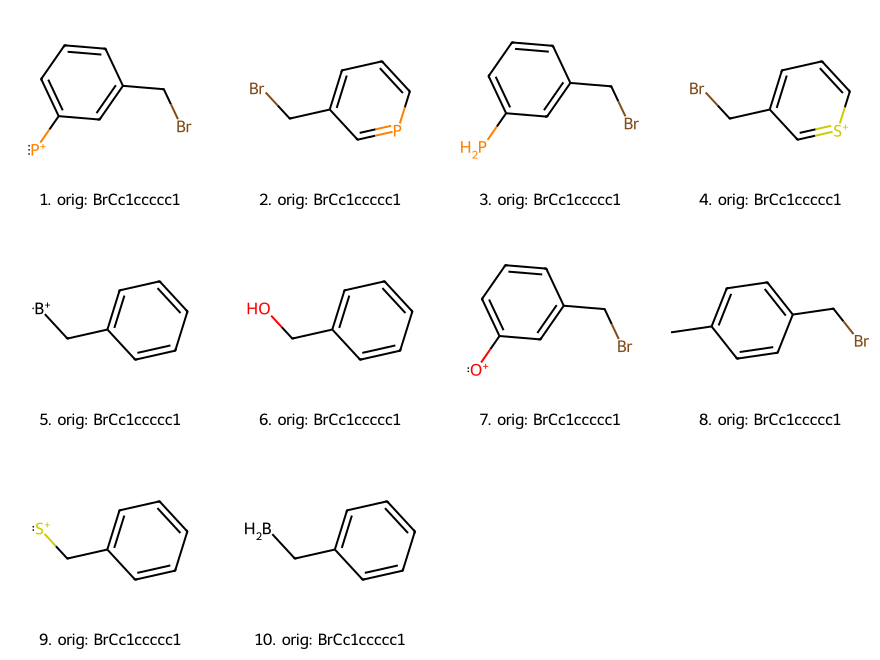

In [19]:
# 可视化：查看去重后 CSV 里的前十个分子的结构式
import os, glob
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display

# 1) 选择去重后的CSV
candidates = [
    "origin_expanded_ecfp4_gt0.6_perMol300_dedup.csv",
    "origin_expanded_ecfp4_gt0.8_dedup.csv",
    "oringinal_expanded_ecfp4_gt0.6_longestPathScaffold_unique_dedup.csv",
    "expanded_molecules_unique_dedup.csv",
    "expanded_molecules_dedup.csv",
 ]
dedup_csv = None
for p in candidates:
    if os.path.exists(p):
        dedup_csv = p
        break
if dedup_csv is None:
    files = sorted(glob.glob("*_dedup.csv"), key=os.path.getmtime, reverse=True)
    if files:
        dedup_csv = files[0]
if dedup_csv is None:
    raise FileNotFoundError("未找到 *_dedup.csv，请先运行上方去重单元生成。")
print(f"可视化输入文件: {dedup_csv}")

# 2) 读取并定位 SMILES 列
df = pd.read_csv(dedup_csv)
if df.shape[0] == 0:
    raise ValueError("去重后的CSV为空")
cand_cols = ["generated_smi","smiles","SMILES","smi","Smi","SMI"]
smi_col = None
for c in cand_cols:
    if c in df.columns:
        smi_col = c
        break
if smi_col is None:
    # 如果标准列名不存在，默认优先 generated_smi，否则选择合理的第一或第二列
    if "generated_smi" in df.columns:
        smi_col = "generated_smi"
    else:
        if df.shape[1] > 1 and df.columns[0] == "original_smi":
            smi_col = df.columns[1]
        else:
            smi_col = df.columns[0]
print(f"识别到 SMILES 列: {smi_col}")

# 3) 准备前10条有效分子与图例
subset = df.head(10).copy()
mols_viz = []
legends = []
for i, row in subset.iterrows():
    smi = str(row[smi_col])
    m = Chem.MolFromSmiles(smi)
    if not m:
        continue
    mols_viz.append(m)
    if "original_smi" in subset.columns:
        legends.append(f"{len(mols_viz)}. orig: {str(row['original_smi'])[:18]}")
    else:
        legends.append(f"{len(mols_viz)}. gen: {smi[:18]}")

if len(mols_viz) == 0:
    raise ValueError("前10条中没有可解析的分子")

# 4) 绘制与展示
img = Draw.MolsToGridImage(mols_viz, molsPerRow=min(4, len(mols_viz)), subImgSize=(220,220), legends=legends)
display(img)

使用CSV: expanded_molecules.csv
识别到分子列: generated_smi
按 original_smi 分组展示，每组 4 个；最多展示 3 组
组 1: original_smi = BrCc1ccccc1
识别到分子列: generated_smi
按 original_smi 分组展示，每组 4 个；最多展示 3 组
组 1: original_smi = BrCc1ccccc1


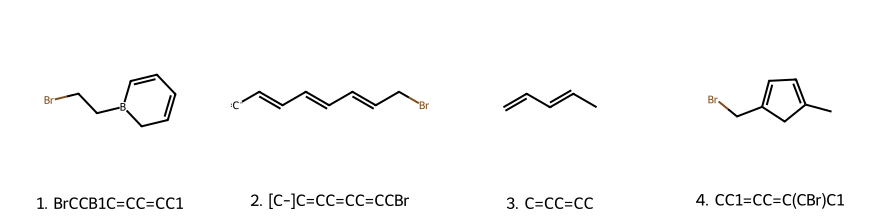

组 2: original_smi = C/C=C/COP(C)(=O)F


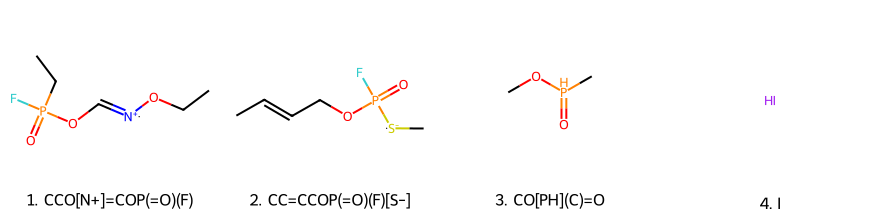

组 3: original_smi = C1CSCCO1


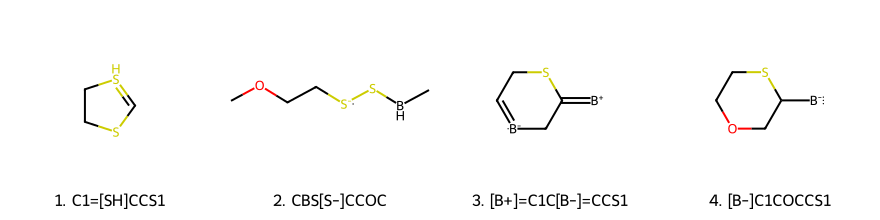

In [21]:
# 可视化（代码内配置版）：手动设置CSV/SMILES列/分组列；每组展示10个结构式
import os, glob
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display

# =========== 配置区域（修改这里） ==========
csv_path        = "expanded_molecules.csv"   # 例如: "origin_expanded_ecfp4_gt0.6_perMol300_dedup.csv"；留空则自动选择
smiles_col_in   = "generated_smi"   # 例如: "generated_smi"；留空自动识别(generated_smi/SMILES/smi等)
group_col_in    = "original_smi"   # 例如: "original_smi"；留空则不分组
groups_to_show  = 3     # 最多展示多少个分组（仅当设置了group_col_in时生效）
mols_per_group  = 4    # 每组展示多少个分子

# =========== 选择CSV ==========
if not csv_path:
    priors = [
        "origin_expanded_ecfp4_gt0.6_perMol300_dedup.csv",
        "origin_expanded_ecfp4_gt0.8_dedup.csv",
        "oringinal_expanded_ecfp4_gt0.6_longestPathScaffold_unique_dedup.csv",
        "expanded_molecules_unique_dedup.csv",
        "expanded_molecules_dedup.csv",
        "origin_expanded_ecfp4_gt0.6_perMol300.csv",
        "origin_expanded_ecfp4_gt0.8.csv",
        "oringinal_expanded_ecfp4_gt0.6_longestPathScaffold_unique.csv",
        "expanded_molecules_unique.csv",
        "expanded_molecules.csv",
    ]
    for p in priors:
        if os.path.exists(p):
            csv_path = p
            break
    if not csv_path:
        files = sorted(glob.glob("*.csv"), key=os.path.getmtime, reverse=True)
        if files:
            csv_path = files[0]
if not csv_path or not os.path.exists(csv_path):
    raise FileNotFoundError("未找到CSV文件，请在配置区域提供有效路径。")
print(f"使用CSV: {csv_path}")

# =========== 读取与列识别 ==========
df = pd.read_csv(csv_path)
if df.shape[0] == 0:
    raise ValueError("CSV为空")

# 分子列识别
smiles_col = smiles_col_in if smiles_col_in else None
cand_cols = ["generated_smi","smiles","SMILES","smi","Smi","SMI"]
if smiles_col is None:
    for c in cand_cols:
        if c in df.columns:
            smiles_col = c
            break
if smiles_col is None:
    if "original_smi" in df.columns and df.shape[1] > 1:
        smiles_col = [c for c in df.columns if c != "original_smi"][0]
    else:
        smiles_col = df.columns[0]
print(f"识别到分子列: {smiles_col}")

# 分组列（可选）
group_col = group_col_in if group_col_in else None
if group_col and group_col not in df.columns:
    print(f"警告：分组列 {group_col} 不存在，改为不分组模式")
    group_col = None

# =========== 绘图函数 ==========
def draw_mols(smiles_list, legends_prefix=None, ncols=4, size=(220,220)):
    mols_viz = []
    legends = []
    for i, smi in enumerate(smiles_list, 1):
        m = Chem.MolFromSmiles(str(smi))
        if not m:
            continue
        mols_viz.append(m)
        if legends_prefix is not None:
            legends.append(f"{i}. {legends_prefix}")
        else:
            legends.append(f"{i}. {str(smi)[:18]}")
    if not mols_viz:
        print("无可解析分子")
        return
    img = Draw.MolsToGridImage(mols_viz, molsPerRow=min(ncols, len(mols_viz)), subImgSize=size, legends=legends)
    display(img)

# =========== 可视化 ==========
if group_col:
    print(f"按 {group_col} 分组展示，每组 {mols_per_group} 个；最多展示 {groups_to_show} 组")
    shown = 0
    for g, sub in df.groupby(group_col):
        if shown >= groups_to_show:
            break
        smiles_vals = sub[smiles_col].dropna().astype(str).head(mols_per_group).tolist()
        if not smiles_vals:
            continue
        print(f"组 {shown+1}: {group_col} = {str(g)[:64]}")
        draw_mols(smiles_vals, legends_prefix=None)
        shown += 1
    if shown == 0:
        print("没有可展示的分组。请检查分组列/分子列是否正确。")
else:
    print(f"未指定分组列，直接展示前 {mols_per_group} 个分子：列 {smiles_col}")
    smiles_vals = df[smiles_col].dropna().astype(str).head(mols_per_group).tolist()
    draw_mols(smiles_vals)